In [1]:
import numpy as np

from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM
from astropy.cosmology import w0waCDM

from cosmosis.gaussian_likelihood import GaussianLikelihood
from cosmosis.datablock import names

import statistics as stat

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pandas as pd

import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm

import nautilus.sampler as ns
from nautilus import Sampler
from nautilus import Prior

import sys
import os

import corner

from anesthetic import NestedSamples

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import h5py

ns.h5py = h5py

print("Hello world")

Hello world


In [2]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus, cosmosis

print("numpy:", numpy.__version__)
print("cosmosis:", cosmosis.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.3.5
cosmosis: 3.25
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


In [3]:
#Likelihood functions for CMB, SN and BAO

def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array([mu_model - mu])
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2

def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

# Load your data

df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

cov_file = "STAT+SYS.npz"

#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a probability of being SN1a over 90%

allowed = [10, 63, 64, 65, 66, 150]

ww = (
    df['IDSURVEY'].isin(allowed) &
    (df['zHD'] >= 0.025) &
    (df['PROBIA_BEAMS'] > 0.9)
)

zCMB = df['zHD'][ww].to_numpy()
zHEL = df['zHEL'][ww].to_numpy()
real_mu = df['MU'][ww].to_numpy()
real_muerr = df['MUERR'][ww].to_numpy()


c = 299792.458

#make no off diagonal sn matrix

SN_sd = []

for i in range(len(real_muerr)):
    SN_sd.append(real_muerr[i]**2)

SN_cov = np.diag(SN_sd)
    
inv_SN = np.linalg.inv(SN_cov)

In [4]:
#Calculate CMB covarience matrix with correlations

corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

CMB_means = np.array([1.7502, 301.471, 0.02236])

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

print("Covariance matrix:\n", cov_CMB)
print("Inverse covariance matrix:\n", inv_CMB)

Covariance matrix:
 [[ 2.11600e-05  1.89382e-04 -4.55400e-07]
 [ 1.89382e-04  8.01025e-03 -4.43025e-06]
 [-4.55400e-07 -4.43025e-06  2.25000e-08]]
Inverse covariance matrix:
 [[ 9.47889969e+04 -1.32415986e+03  1.65780222e+06]
 [-1.32415986e+03  1.58594485e+02  4.42625856e+03]
 [ 1.65780222e+06  4.42625856e+03  7.88698917e+07]]


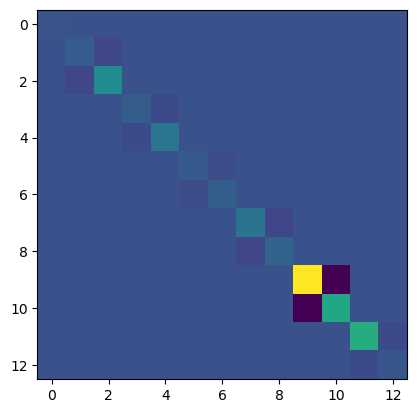

In [5]:
#BAO COV matrix calculated with correlations:

zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_real = np.array([7.942, 13.588, 21.863, 17.351, 19.455, 21.576, 17.641, 27.601, 14.176, 30.512, 12.817, 38.988, 8.632])
BAO_errors = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]
BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]

for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1   # Dm index
    dh_idx = 2*i + 2   # Dh index

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

plt.imshow(BAO_cov)

In [6]:
#All likelyhoods and priors laid out as in the paper

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, inv_SN)
    
    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]
        
        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]
        
        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]
        
        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################
    
#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Combination of likelihoods for different probes

def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)

In [7]:


####################################### Estimation

samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"nocov_w0wa.h5")
samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, filepath = f"nocov_w.h5")
samplerSN_CMB_BAO_wCDM_est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"nocov_L.h5")
samplerSN_CMB_BAO_LCDM_est.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39200    | N/A    | 10050 | -834.62  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 68400    | N/A    | 14709 | -842.48  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10007 | -843.09  


np.True_

log Z: -834.62
log Z: -842.48
log Z: -843.09
w0waCDM
Om0 median = 0.31841
Om0 - = 0.00452
Om0 + = 0.00449
w0 median = -0.75581
w0 - = 0.04786
w0 + = 0.05037
wa median = -0.91107
wa - = 0.23689
wa + = 0.22483
H0 median = 67.26946
H0 - = 0.42913
H0 + = 0.43452
wCDM
Om0 median = 0.31299
Om0 - = 0.00411
Om0 + = 0.00417
w0 median = -0.94509
w0 - = 0.01815
w0 + = 0.01775
H0 median = 67.19569
H0 - = 0.42478
H0 + = 0.42729
LCDM
Om0 median = 0.30700
Om0 - = 0.00363
Om0 + = 0.00365
H0 median = 68.19498
H0 - = 0.27123
H0 + = 0.28484


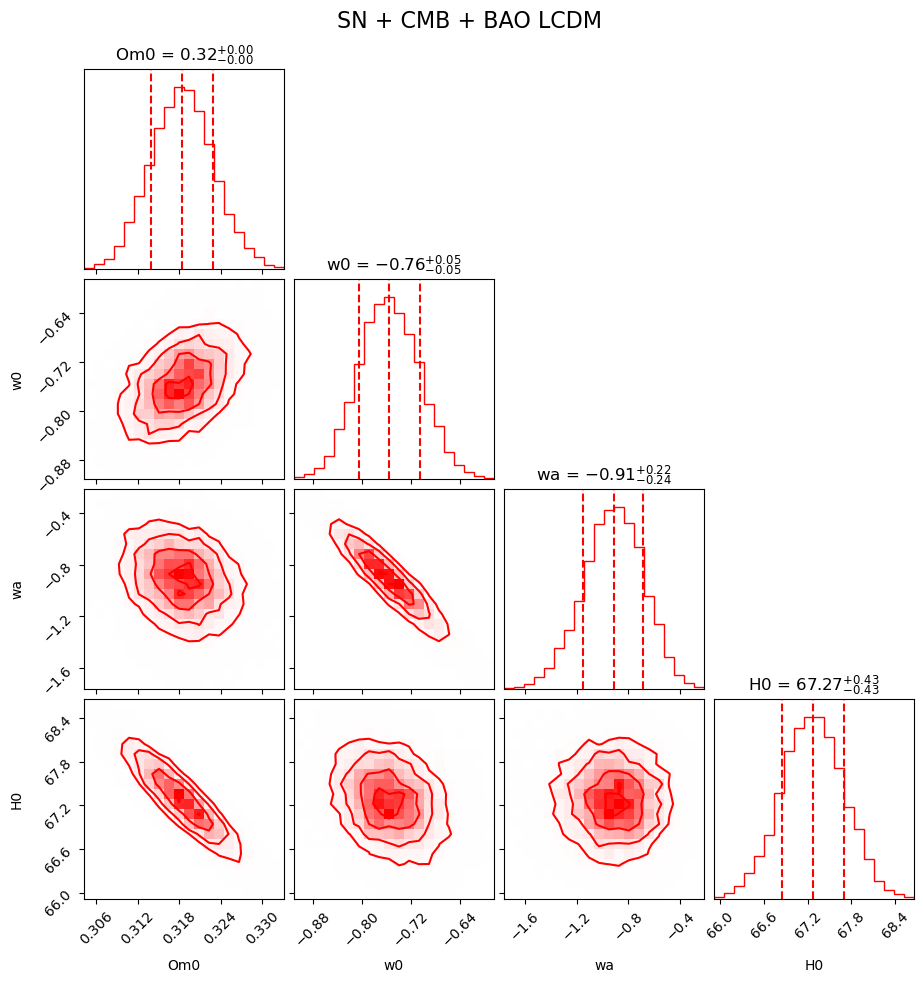

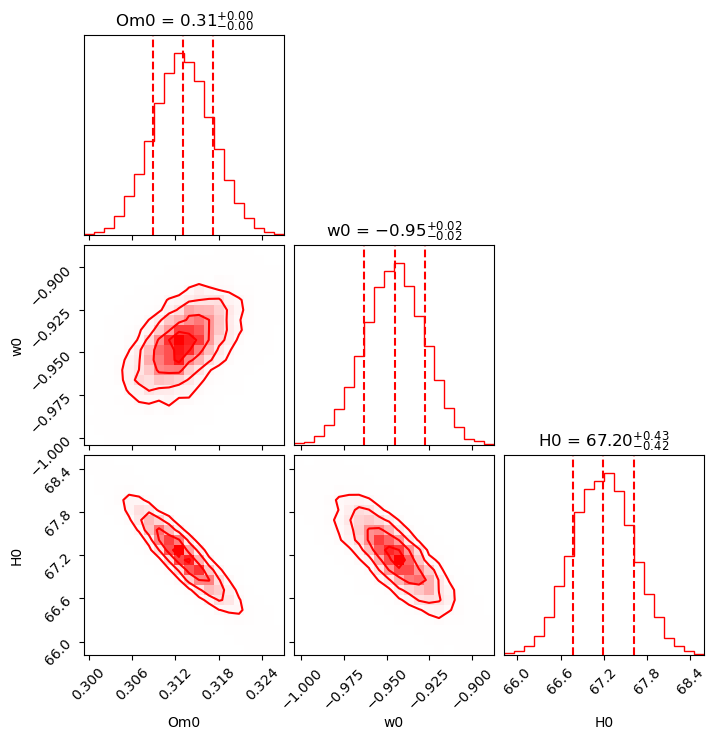

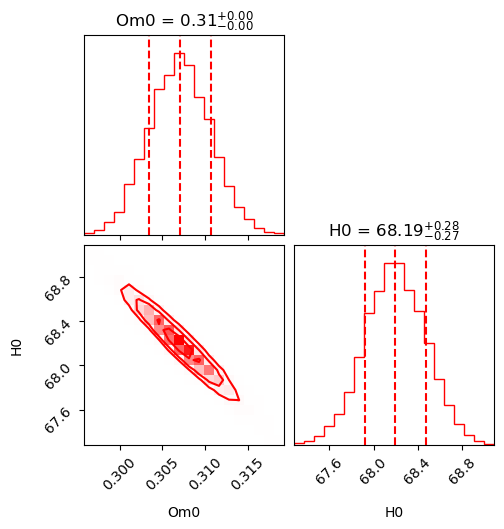

In [8]:
#Plot corner graphs

points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()

# Parameters wanted
keepSN_CMB_BAO_w0waCDM_est = ['Om0', 'w0', 'wa', 'H0']

# Original labels in the order of points_2 columns
all_labelsSN_CMB_BAO_w0waCDM_est = list(prior_w0waCDM_est.keys)

# Indices of the parameters to keep
idxSN_CMB_BAO_w0waCDM_est = [all_labelsSN_CMB_BAO_w0waCDM_est.index(p) for p in keepSN_CMB_BAO_w0waCDM_est]

# Slice samples
points_selSN_CMB_BAO_w0waCDM_est = points_SN_CMB_BAO_w0waCDM_est[:, idxSN_CMB_BAO_w0waCDM_est]

# Corner plot
fig = corner.corner(points_selSN_CMB_BAO_w0waCDM_est, weights=np.exp(log_w_SN_CMB_BAO_w0waCDM_est), bins=20, labels=keepSN_CMB_BAO_w0waCDM_est, color='red', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_w0waCDM_est)), quantiles=[0.1585, 0.5, 0.8415], show_titles=True, title_kwargs={"fontsize": 12})

print('log Z: {:.2f}'.format(samplerSN_CMB_BAO_w0waCDM_est.log_z))





points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()

keepSN_CMB_BAO_wCDM_est = ['Om0', 'w0', 'H0']

all_labelsSN_CMB_BAO_wCDM_est = list(prior_wCDM_est.keys)

idxSN_CMB_BAO_wCDM_est = [all_labelsSN_CMB_BAO_wCDM_est.index(p) for p in keepSN_CMB_BAO_wCDM_est]

points_selSN_CMB_BAO_wCDM_est = points_SN_CMB_BAO_wCDM_est[:, idxSN_CMB_BAO_wCDM_est]

fig4 = corner.corner(points_selSN_CMB_BAO_wCDM_est, weights=np.exp(log_w_SN_CMB_BAO_wCDM_est), bins=20, labels=keepSN_CMB_BAO_wCDM_est, color='red', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_wCDM_est)), quantiles=[0.1585, 0.5, 0.8415], show_titles=True, title_kwargs={"fontsize": 12})

fig.suptitle("SN + CMB + BAO wCDM", fontsize=16, y=1.02)

print('log Z: {:.2f}'.format(samplerSN_CMB_BAO_wCDM_est.log_z))






points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()

keepSN_CMB_BAO_LCDM_est = ['Om0', 'H0']

all_labelsSN_CMB_BAO_LCDM_est = list(prior_LCDM_est.keys)

idxSN_CMB_BAO_LCDM_est = [all_labelsSN_CMB_BAO_LCDM_est.index(p) for p in keepSN_CMB_BAO_LCDM_est]

points_selSN_CMB_BAO_LCDM_est = points_SN_CMB_BAO_LCDM_est[:, idxSN_CMB_BAO_LCDM_est]

fig8 = corner.corner(points_selSN_CMB_BAO_LCDM_est, weights=np.exp(log_w_SN_CMB_BAO_LCDM_est), bins=20, labels=keepSN_CMB_BAO_LCDM_est, color='red', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_LCDM_est)), quantiles=[0.1585, 0.5, 0.8415], show_titles=True, title_kwargs={"fontsize": 12})

fig.suptitle("SN + CMB + BAO LCDM", fontsize=16, y=1.02)

print('log Z: {:.2f}'.format(samplerSN_CMB_BAO_LCDM_est.log_z))

#Extract best fit point and standard errors

print("w0waCDM")

weights = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
q50 = np.zeros(5)
q16 = np.zeros(5)
q84 = np.zeros(5)

for i, p in enumerate(keepSN_CMB_BAO_w0waCDM_est):
    q50[i] = corner.quantile(points_selSN_CMB_BAO_w0waCDM_est[:, i], [0.5], weights=weights)[0]
    q16[i] = q50[i] - corner.quantile(points_selSN_CMB_BAO_w0waCDM_est[:, i], [0.1585], weights=weights)[0]
    q84[i] = corner.quantile(points_selSN_CMB_BAO_w0waCDM_est[:, i], [0.8415], weights=weights)[0] - q50[i]
    print(f"{p} median = {q50[i]:.5f}")
    print(f"{p} - = {q16[i]:.5f}")
    print(f"{p} + = {q84[i]:.5f}")
    
print("wCDM")
    
weightsw = np.exp(log_w_SN_CMB_BAO_wCDM_est)
q50w = np.zeros(5)
q16w = np.zeros(5)
q84w = np.zeros(5)

for i, p in enumerate(keepSN_CMB_BAO_wCDM_est):
    q50w[i] = corner.quantile(points_selSN_CMB_BAO_wCDM_est[:, i], [0.5], weights=weightsw)[0]
    q16w[i] = q50w[i] - corner.quantile(points_selSN_CMB_BAO_wCDM_est[:, i], [0.1585], weights=weightsw)[0]
    q84w[i] = corner.quantile(points_selSN_CMB_BAO_wCDM_est[:, i], [0.8415], weights=weightsw)[0] - q50w[i]
    print(f"{p} median = {q50w[i]:.5f}")
    print(f"{p} - = {q16w[i]:.5f}")
    print(f"{p} + = {q84w[i]:.5f}")
    
print("LCDM")
    
weightsL = np.exp(log_w_SN_CMB_BAO_LCDM_est)
q50L = np.zeros(5)
q16L = np.zeros(5)
q84L = np.zeros(5)

for i, p in enumerate(keepSN_CMB_BAO_LCDM_est):
    q50L[i] = corner.quantile(points_selSN_CMB_BAO_LCDM_est[:, i], [0.5], weights=weightsL)[0]
    q16L[i] = q50L[i] - corner.quantile(points_selSN_CMB_BAO_LCDM_est[:, i], [0.1585], weights=weightsL)[0]
    q84L[i] = corner.quantile(points_selSN_CMB_BAO_LCDM_est[:, i], [0.8415], weights=weightsL)[0] - q50L[i]
    print(f"{p} median = {q50L[i]:.5f}")
    print(f"{p} - = {q16L[i]:.5f}")
    print(f"{p} + = {q84L[i]:.5f}")